# Evaluation of distribution of models on 60km -> 2.2km-4x over Birmingham

In [ ]:
%reload_ext autoreload

%autoreload 2

%reload_ext dotenv
%dotenv

In [ ]:
from mlde_analysis.default_params import *

In [ ]:
# Parameters
desc = "Comparison of diffusion model arch sizes for CPMGEM-pr paper\nTest split\n12em dataset and models, 60km inputs -> 8.8km outputs, pSTV input variable set\nCompare: xs, small, medium, CPMGEM for cCPM inputs\n"
eval_vars = ["pr"]
derived_variables_config = {}
dataset_configs = {"CPM": "bham64_ccpm-4x_12em_psl-sphum4th-temp4th-vort4th_pr"}
split = "test"
ensemble_members = [
    "01",
    "04",
    "05",
    "06",
    "07",
    "08",
    "09",
    "10",
    "11",
    "12",
    "13",
    "15",
]
samples_per_run = 6
sample_configs = {
    "CPM": [
        {
            "label": "xs",
            "sample_specs": [
                {
                    "fq_model_id": "score-sde/subvpsde/ukcp_local_pr_12em_cncsnpp_continuous_xs/bham-4x_12em_pSTV",
                    "checkpoint": "epoch_20",
                    "config_hash": "65f22cdf700a3331",
                    "input_xfm": "bham64_ccpm-4x_12em_psl-sphum4th-temp4th-vort4th_pr-stan",
                    "dataset": "bham64_ccpm-4x_12em_psl-sphum4th-temp4th-vort4th_pr",
                    "variables": ["pr"],
                }
            ],
            "deterministic": False,
            "CCS": True,
            "color": "tab:red",
            "order": 1,
        },
        {
            "label": "small",
            "sample_specs": [
                {
                    "fq_model_id": "score-sde/subvpsde/ukcp_local_pr_12em_cncsnpp_continuous_small/bham-4x_12em_pSTV",
                    "checkpoint": "epoch_20",
                    "config_hash": "24fb5beaf6630470",
                    "input_xfm": "bham64_ccpm-4x_12em_psl-sphum4th-temp4th-vort4th_pr-stan",
                    "dataset": "bham64_ccpm-4x_12em_psl-sphum4th-temp4th-vort4th_pr",
                    "variables": ["pr"],
                }
            ],
            "deterministic": False,
            "CCS": True,
            "color": "tab:orange",
            "order": 2,
        },
        {
            "label": "med",
            "sample_specs": [
                {
                    "fq_model_id": "score-sde/subvpsde/ukcp_local_pr_12em_cncsnpp_continuous_medium/bham-4x_12em_pSTV",
                    "checkpoint": "epoch_20",
                    "config_hash": "e4a2ab8cb5f58326",
                    "input_xfm": "bham64_ccpm-4x_12em_psl-sphum4th-temp4th-vort4th_pr-stan",
                    "dataset": "bham64_ccpm-4x_12em_psl-sphum4th-temp4th-vort4th_pr",
                    "variables": ["pr"],
                }
            ],
            "deterministic": False,
            "CCS": True,
            "color": "tab:olive",
            "order": 3,
        },
        {
            "label": "large",
            "sample_specs": [
                {
                    "fq_model_id": "score-sde/subvpsde/ukcp_local_pr_12em_cncsnpp_continuous/bham-4x_12em_pSTV",
                    "checkpoint": "epoch_20",
                    "input_xfm": "bham64_ccpm-4x_12em_psl-sphum4th-temp4th-vort4th_pr-stan",
                    "dataset": "bham64_ccpm-4x_12em_psl-sphum4th-temp4th-vort4th_pr",
                    "variables": ["pr"],
                }
            ],
            "deterministic": False,
            "CCS": True,
            "color": "tab:blue",
            "order": 11,
        },
    ]
}
example_percentiles = {
    "CPM": {
        "DJF Wet": {"percentile": 0.8, "variable": "pr", "season": "DJF"},
        "DJF Wettest": {"percentile": 1, "variable": "pr", "season": "DJF"},
        "JJA Wet": {"percentile": 0.8, "variable": "pr", "season": "JJA"},
        "JJA Wettest": {"percentile": 1, "variable": "pr", "season": "JJA"},
    }
}
example_overrides = {"CPM": {"JJA Wet": ["01", "1993-08-01 12:00:00"]}}
examples_sample_idxs = 1
example_inputs = []
niterations = 30
bootstrap_configs = {"niterations": {"spread-error": 100}}


In [ ]:
import functools
import math
import string

import IPython
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

from mlde_analysis import plot_map, SUBREGIONS, BOX_LOCATIONS
from mlde_analysis.display import pretty_table, VAR_RANGES
from mlde_analysis.distribution import mean_bias, std_bias, stat_bias, plot_freq_density, plot_distribution_figure, compute_metrics, DIST_THRESHOLDS
from mlde_analysis.wet_dry import threshold_exceeded_prop_stats, threshold_exceeded_prop, threshold_exceeded_prop_error, threshold_exceeded_prop_change, plot_threshold_exceedence_errors, THRESHOLDS, wd_mean, wd_mean_bias
from mlde_utils import cp_model_rotated_pole
from mlde_analysis import qq_plot, reasonable_quantiles

In [ ]:
matplotlib.rcParams['figure.dpi'] = 300

In [ ]:
IPython.display.Markdown(desc)

Comparison of diffusion model arch sizes for CPMGEM-pr paper
Test split
12em dataset and models, 60km inputs -> 8.8km outputs, pSTV input variable set
Compare: xs, small, medium, CPMGEM for cCPM inputs


In [ ]:
%reload_ext mlde_analysis.magics 
EVAL_DS, MODELS, CPM_DAS, PRED_DAS, VAR_DAS, MODELLABEL2SPEC = %load_eval_data
EVAL_DS

{'CPM': <xarray.Dataset> Size: 27GB
 Dimensions:                     (model: 4, sample_id: 6, ensemble_member: 12,
                                  time: 3240, grid_latitude: 64,
                                  grid_longitude: 64, bnds: 2)
 Coordinates:
   * time                        (time) object 26kB 1981-03-01 12:00:00 ... 20...
     season                      (time) float64 26kB 1.0 1.0 1.0 ... 2.0 2.0 2.0
   * grid_latitude               (grid_latitude) float32 256B -2.49 ... 2.55
   * grid_longitude              (grid_longitude) float32 256B 357.9 ... 363.0
   * ensemble_member             (ensemble_member) <U2 96B '01' '04' ... '15'
   * model                       (model) object 32B 'xs' 'small' 'med' 'large'
     time_period                 (time) <U8 104kB 'historic' ... 'future'
     dec_adjusted_year           (time) int64 26kB 1981 1981 1981 ... 2076 2076
     stratum                     (time) <U12 156kB 'historic MAM' ... 'future ...
     tp_season_year            

## Figure: distribution

* Frequency Density Histogram of rainfall intensities
* Maps of Mean bias ($\frac{\mu_{sample}-\mu_{CPM}}{\mu_{CPM}}$) over all samples, time and ensemble members
* Std Dev Bias $\frac{\sigma_{sample}}{\sigma_{CPM}}$ over all samples, time and ensemble members

Table of:

* RMS biases
* J-S Distances
* proportion of density over thresholds

### pr

,NaN Count,RMS Mean Bias (mm/day),RMS Std Dev Bias (mm/day),quantile,RMS Q999 Bias (mm/day),Relative RMS Mean Bias (%),Relative RMS Std Dev Bias (%),Relative RMS Q999 Bias (%),J-S distance,Emu > 0.1,Emu > 0.1 - CPM > 0.1,Emu > 25,Emu > 25 - CPM > 25,Emu > 75,Emu > 75 - CPM > 75,Emu > 125,Emu > 125 - CPM > 125
model,,,,,,,,,,,,,,,,,
xs,0,0.08916,0.1657,0.999,2.864,3.355,3.181,6.098,0.002358,0.5321,0.002044,0.009642,-0.000228,7.786e-05,-3.716e-05,2.557e-06,-2.523e-06
small,0,0.08245,0.1527,0.999,2.532,2.271,2.712,5.734,0.00198,0.5295,-0.0005074,0.009892,2.109e-05,9.233e-05,-2.269e-05,3.619e-06,-1.461e-06
med,0,0.07577,0.1435,0.999,2.236,2.274,2.581,5.036,0.0008005,0.5288,-0.001246,0.009858,-1.202e-05,0.0001033,-1.17e-05,3.782e-06,-1.298e-06
large,0,0.08922,0.1836,0.999,2.486,3.403,3.567,5.62,0.002809,0.5257,-0.004364,0.009527,-0.0003431,0.0001017,-1.333e-05,4.547e-06,-5.327e-07


6.2793370627572015e-09
5e-10


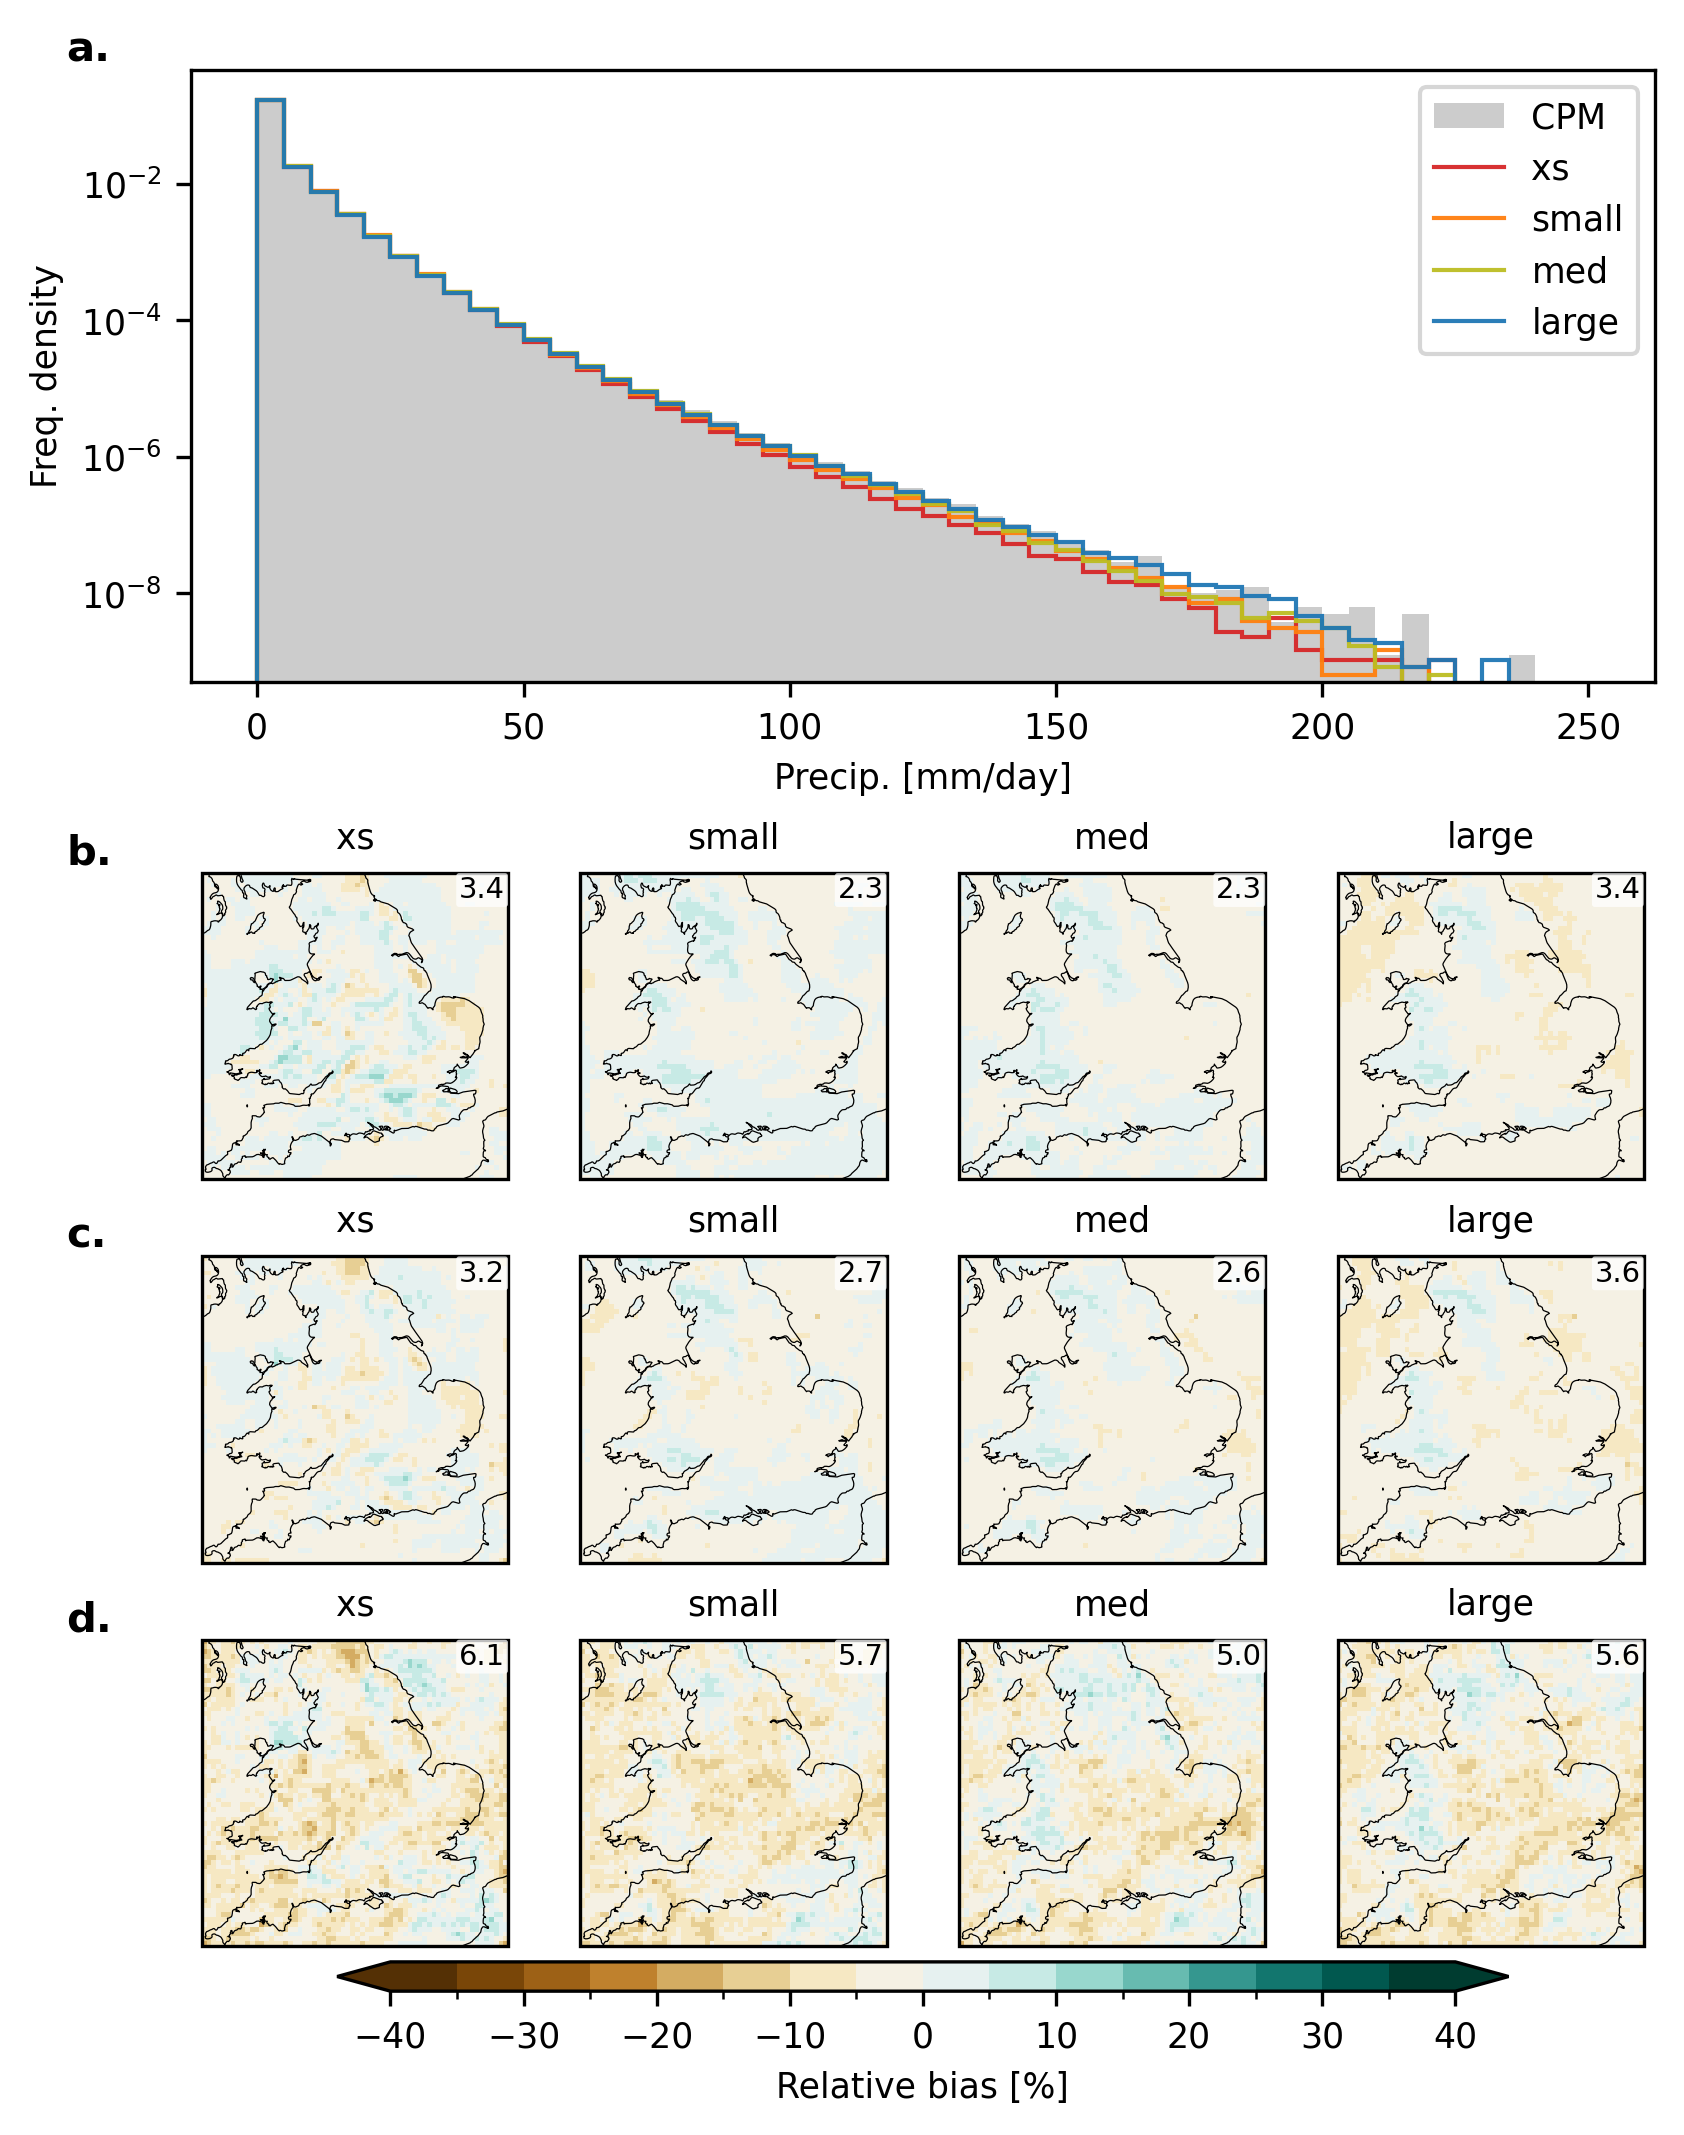

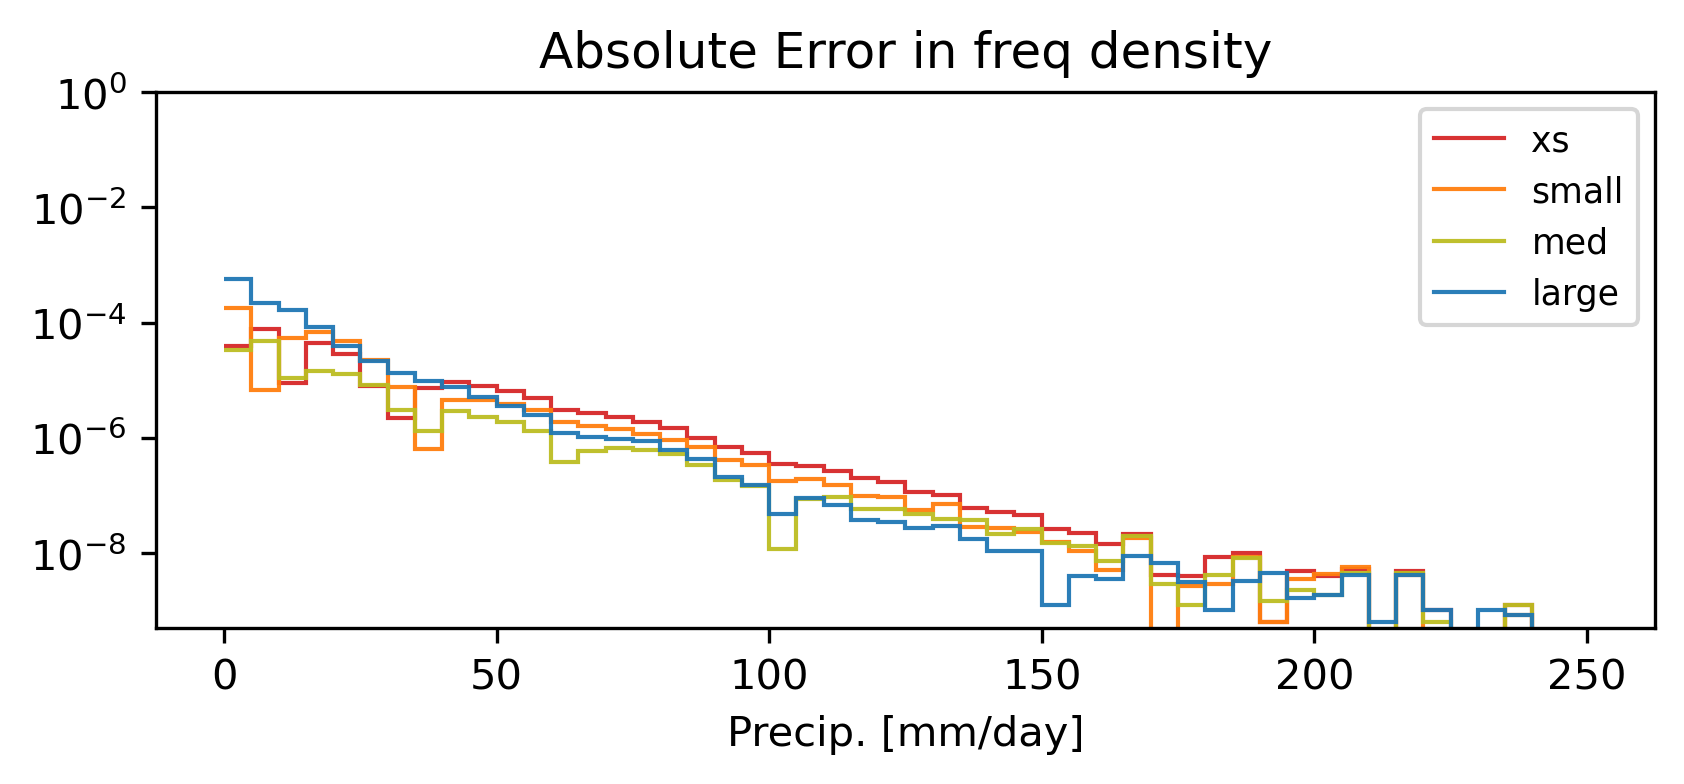

6.2793370627572015e-09
5e-10


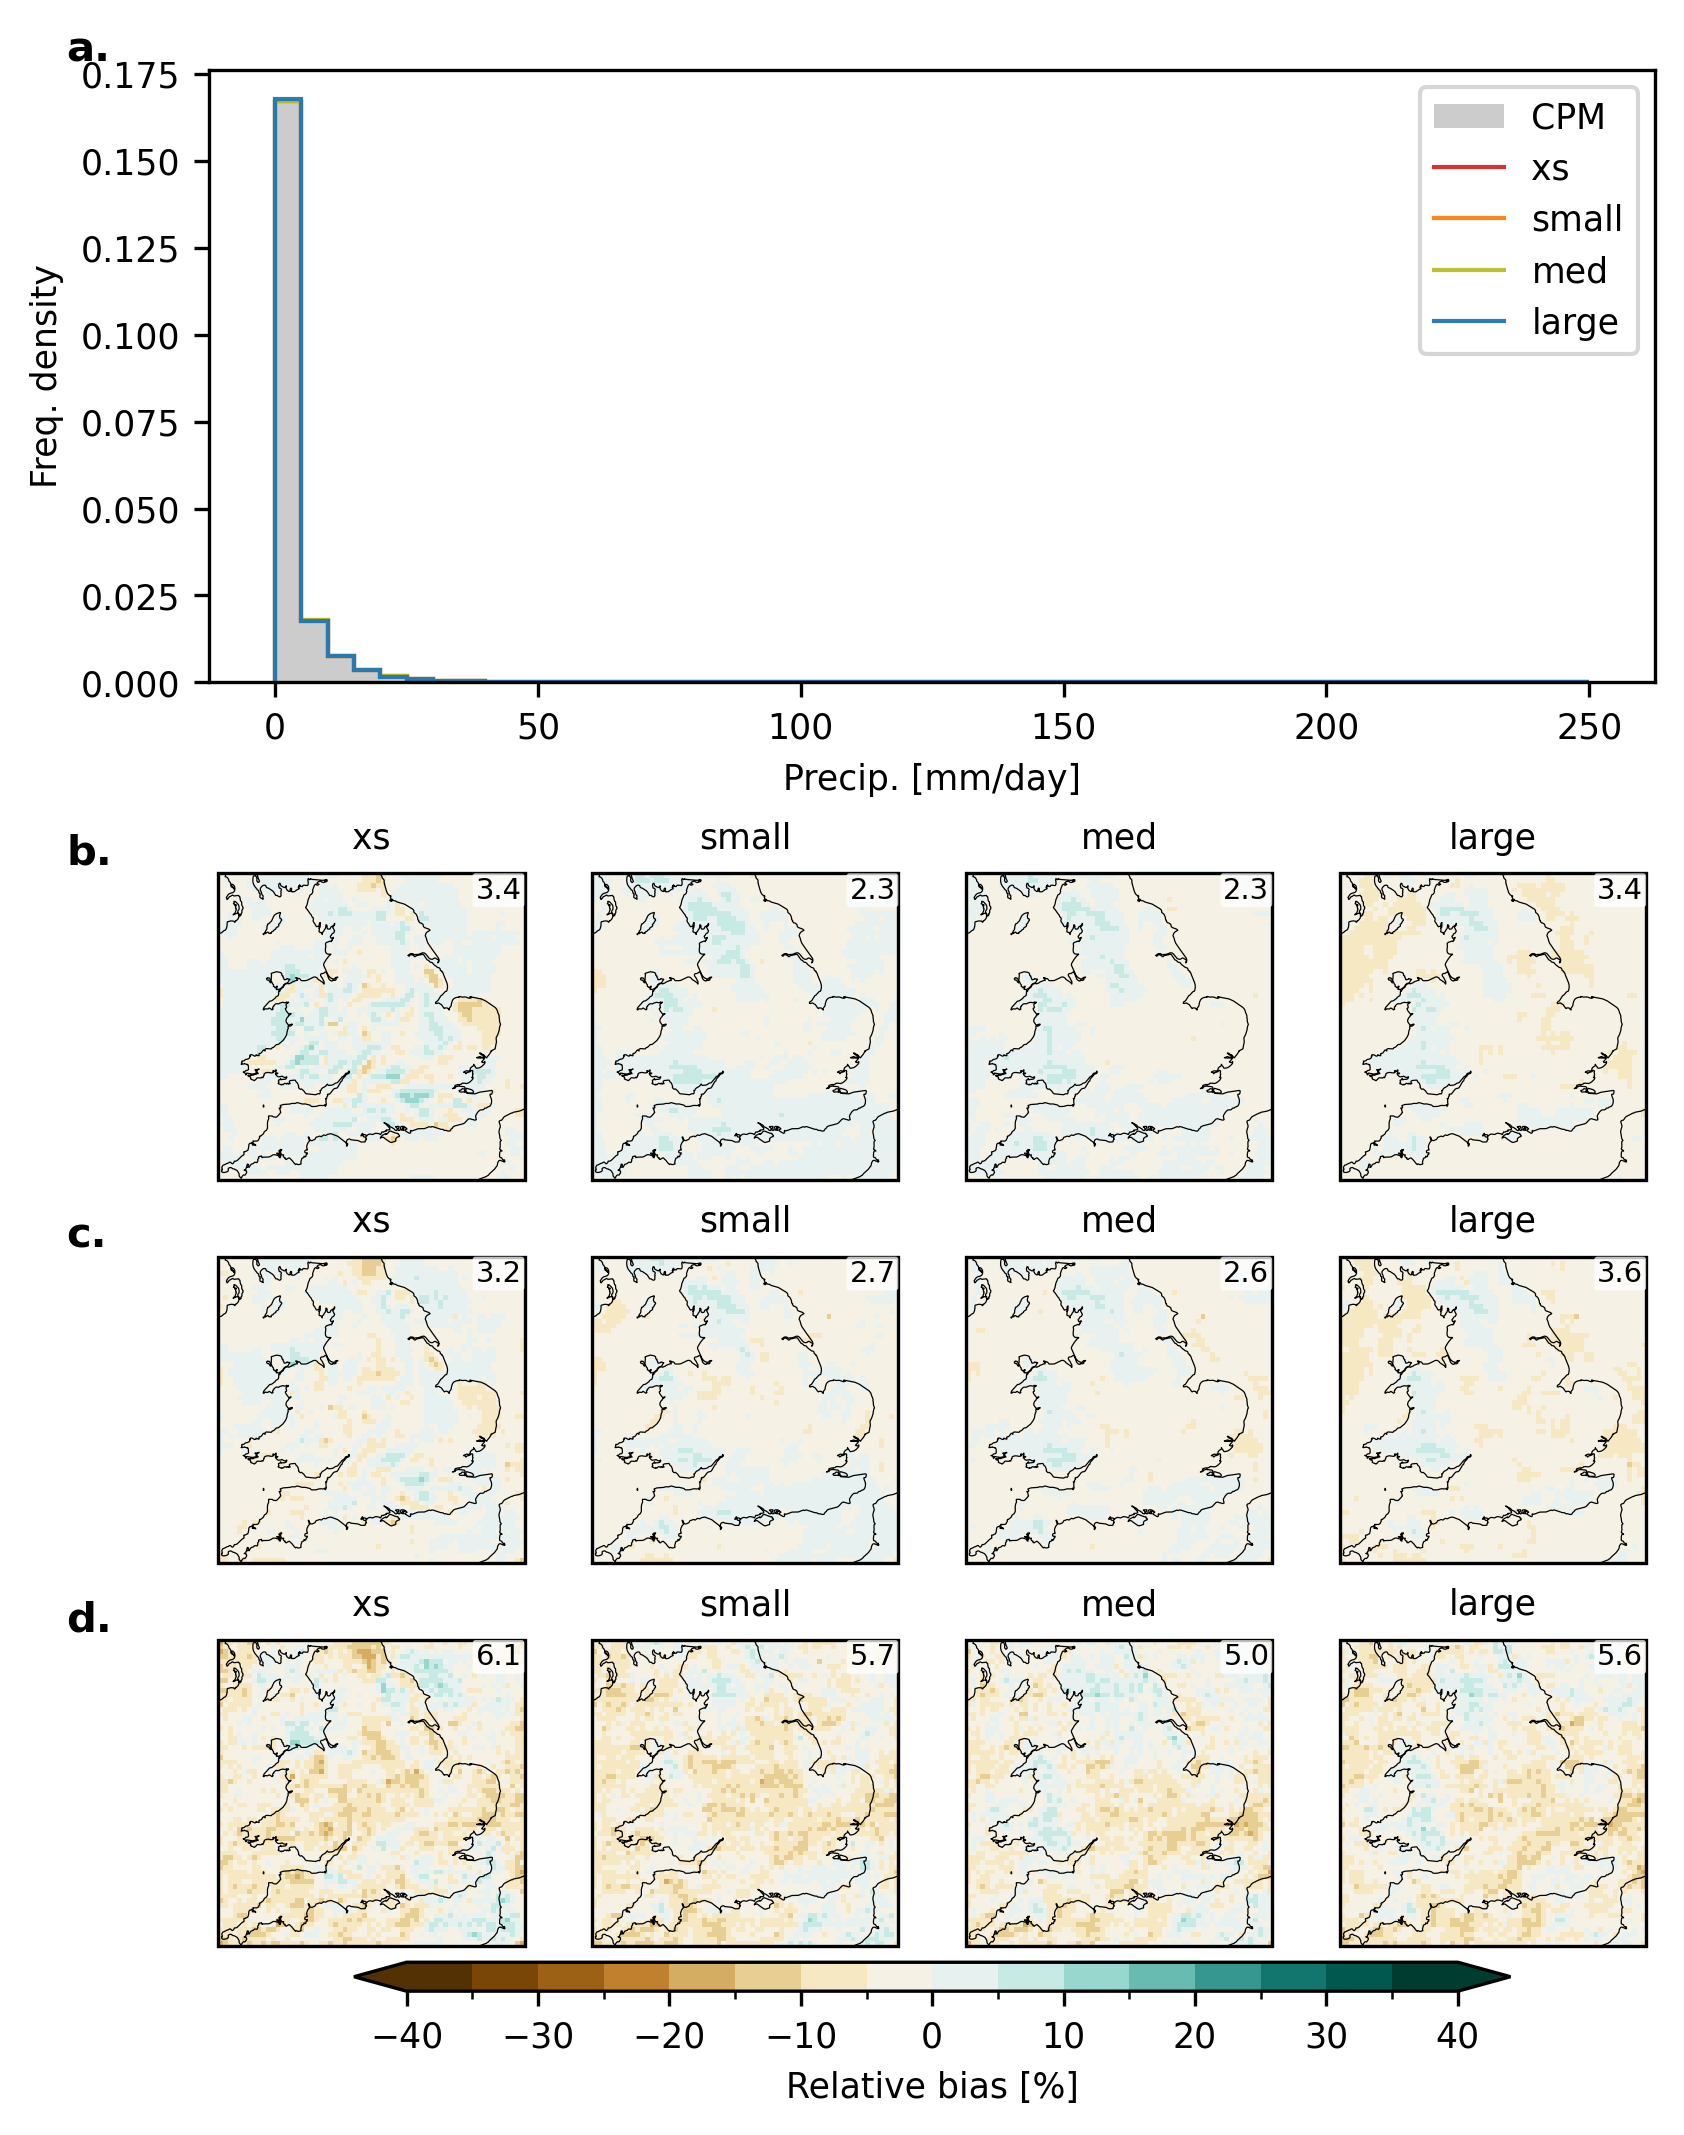

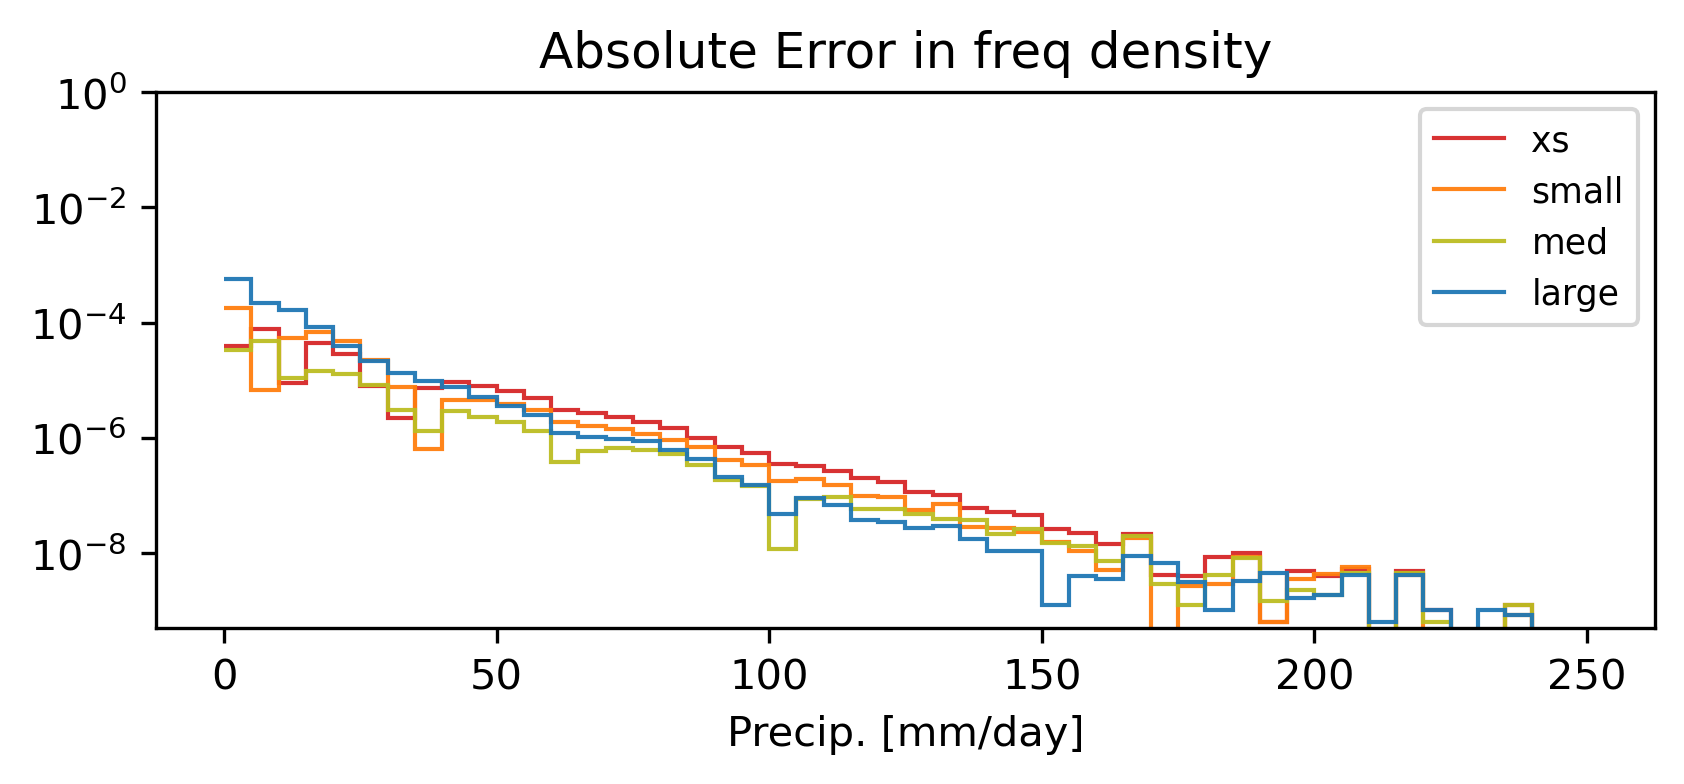

In [ ]:
for var in eval_vars:
    IPython.display.display_markdown(f"### {var}", raw=True)
    
    hist_das = PRED_DAS[var]
    cpm_da = CPM_DAS[var]
    
    metrics_ds = compute_metrics(hist_das, cpm_da, thresholds=DIST_THRESHOLDS[var])

    pretty_table(metrics_ds, round=4)
    
    normalize=(var == "pr")
    mean_biases = PRED_DAS[var].groupby("model").map(mean_bias, cpm_da=VAR_DAS[var][f"target_{var}"], normalize=(var=="pr"))

    std_biases = PRED_DAS[var].groupby("model").map(std_bias, cpm_da=VAR_DAS[var][f"target_{var}"], normalize=(var=="pr"))
    f_q999_bias = functools.partial(stat_bias, stat_func=functools.partial(xr.DataArray.quantile, q=0.999))
    q999_biases = PRED_DAS[var].groupby("model").map(f_q999_bias, cpm_da=VAR_DAS[var][f"target_{var}"], normalize=(var=="pr"))
    
    bias_kwargs = {"style": f"{var}Bias"}
    for fd_kwargs in [{"yscale": "log"}, {"yscale": "linear"}]:
        fig = plt.figure(layout="constrained", figsize=(5.5, 7))
        error_fig = plt.figure(layout="constrained", figsize=(5.5, 2.5))
        error_axd = error_fig.subplot_mosaic([["Error"]])
        error_ax = error_axd["Error"]
        axd = plot_distribution_figure(
            fig,
            hist_das,
            cpm_da,
            mean_biases,
            std_biases,
            q999_biases,
            MODELLABEL2SPEC,
            error_ax=error_ax, hrange=VAR_RANGES[var], fd_kwargs=fd_kwargs, bias_kwargs=bias_kwargs
        )
        if var == "relhum150cm":
            axd["Density"].axvline(x=100, color='k', linestyle='--', linewidth=1)
        
        plt.show()

## QQ plots

### pr

-8


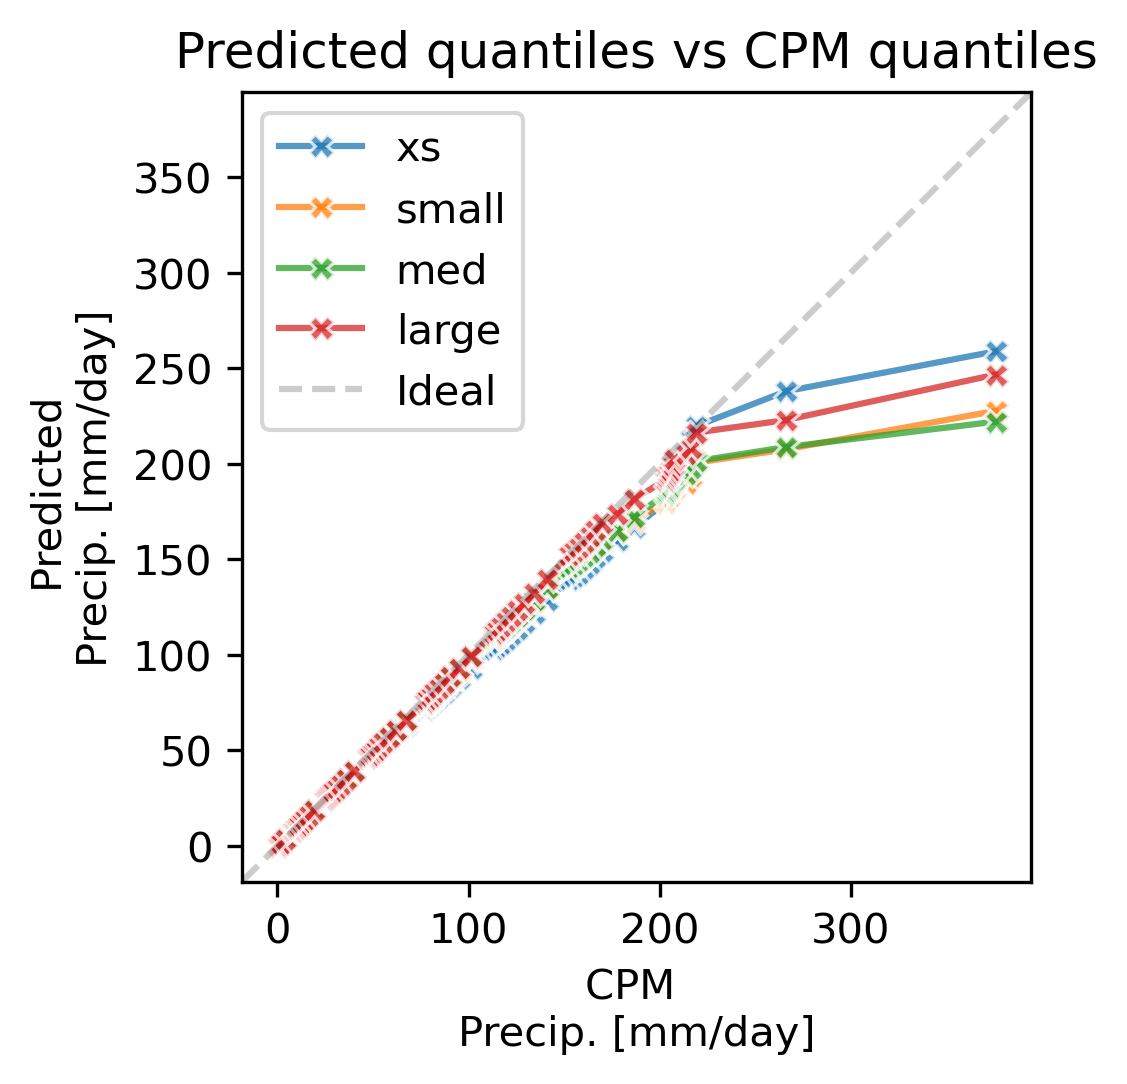

In [ ]:
quantile_dims=["ensemble_member", "time", "grid_latitude", "grid_longitude"]

for var in eval_vars:
    IPython.display.display_markdown(f"### {var}", raw=True)

    quantiles = reasonable_quantiles(CPM_DAS[var])
    cpm_quantiles = CPM_DAS[var].quantile(quantiles, dim=quantile_dims).rename("target_q")

    for source, ds in EVAL_DS.items():
        pred_da = ds[f"pred_{var}"]
        pred_quantiles = pred_da.quantile(quantiles, dim=quantile_dims).rename("pred_q")

        layout="constrained"

        fig, ax = plt.subplots(figsize=(3.5, 3.5), layout="constrained")

        xlabel = f"CPM \n{xr.plot.utils.label_from_attrs(da=CPM_DAS[var])}"
        ylabel = f"Predicted \n{xr.plot.utils.label_from_attrs(da=pred_da)}"

        qq_plot(ax, cpm_quantiles, pred_quantiles, title=f"Predicted quantiles vs CPM quantiles", xlabel=xlabel, ylabel=ylabel)

    plt.show()

## Figure: subdomain

### pr

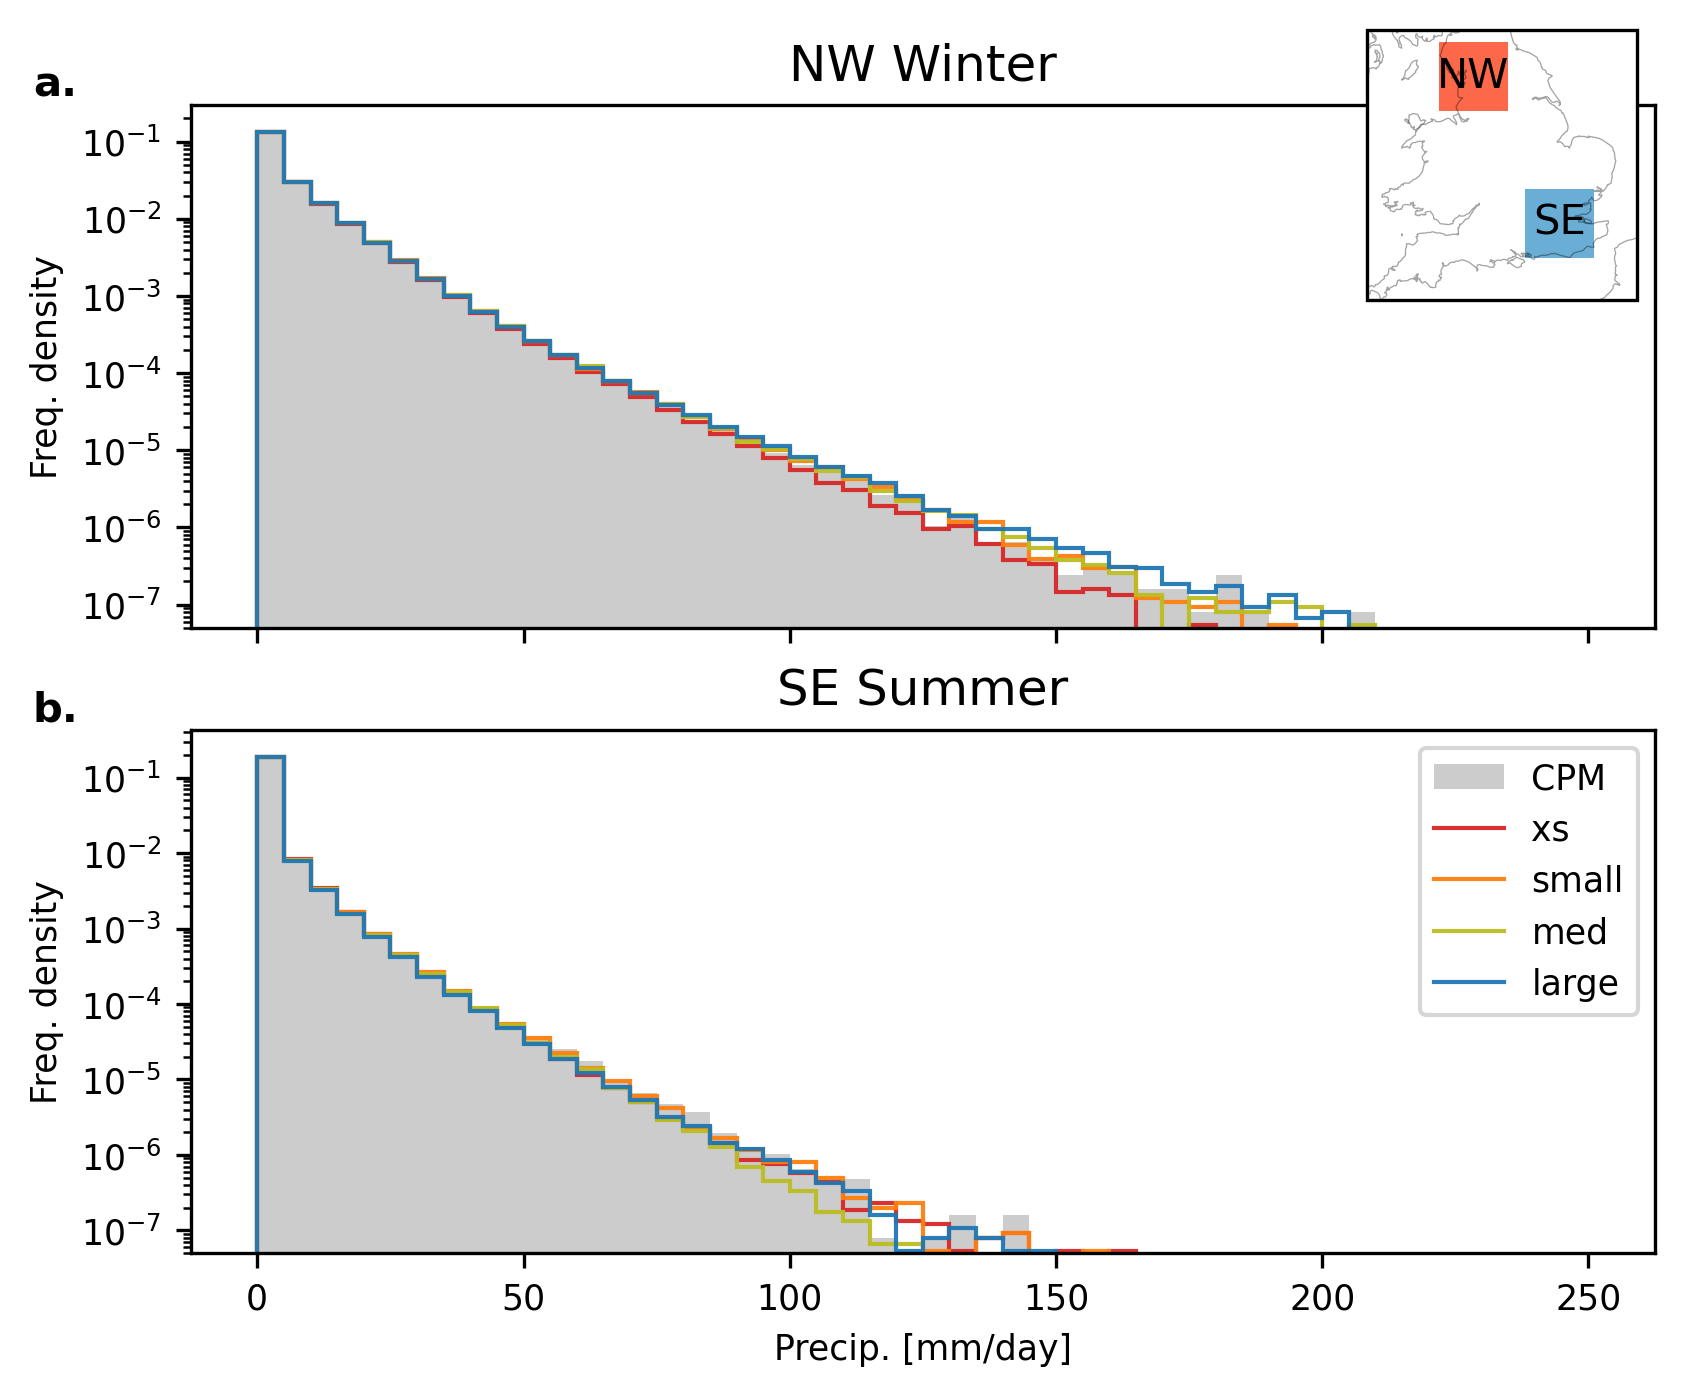

In [ ]:
for var in eval_vars:
    IPython.display.display_markdown(f"### {var}", raw=True)

    fd_fig = plt.figure(figsize=(5.5, 4.5), layout="constrained")

    human_names = {
        "DJF": "Winter",
        "JJA": "Summer",
    }

    axd = fd_fig.subplot_mosaic([["NW"], ["SE"]], sharex=True)
    
    for i, (srname, season) in enumerate([("NW", "DJF"), ("SE", "JJA")]):

        season_mask = CPM_DAS[var]["time"]["time.season"] == season

        srseason_cpm_da = CPM_DAS[var].isel(**SUBREGIONS[srname]).sel(time=season_mask)

        srseason_hist_data = [
            dict(data=EVAL_DS[source][f"pred_{var}"].sel(model=model).isel(**SUBREGIONS[srname]).sel(time=season_mask), label=model, color=spec["color"]) for source, mconfigs in MODELS.items() for model, spec in mconfigs.items()
        ]

        ax = axd[srname]
        if var == "pr":
            kwargs = {
                "yscale": "log",
            }
        else:
            kwargs = {
                "yscale": "linear",
            }
        plot_freq_density(srseason_hist_data, ax=ax, target_da=srseason_cpm_da, linewidth=1, hrange=VAR_RANGES[var], **kwargs)
        ax.set_title(f"{srname} {human_names[season]}")

        if i == 0:
            ax.set_xlabel("")
            ax.get_legend().remove()
            reg_ax = fd_fig.add_axes([0.8, 0.8, 0.2, 0.2], projection=cp_model_rotated_pole)
            # reg_ax = fd_fig.subplots(1, subplot_kw = dict(projection=cp_model_rotated_pole))
            nw_cpm_da = CPM_DAS[var].isel(**SUBREGIONS["NW"])
            se_cpm_da = CPM_DAS[var].isel(**SUBREGIONS["SE"])
            plot_map(10*xr.ones_like(nw_cpm_da.isel(ensemble_member=0, time=0)), ax=reg_ax, style=None, cmap="Reds", cl_kwargs=dict(alpha=0.2))
            plot_map(1*xr.ones_like(se_cpm_da.isel(ensemble_member=0, time=0)), ax=reg_ax, style=None, cmap="Blues", cl_kwargs=dict(alpha=0.2))
            reg_ax.annotate("NW", xy=(nw_cpm_da.grid_longitude.mean().values.item(), nw_cpm_da.grid_latitude.mean().values.item()), xycoords="data", fontsize="medium", ha="center", va="center")
            reg_ax.annotate("SE", xy=(se_cpm_da.grid_longitude.mean().values.item(), se_cpm_da.grid_latitude.mean().values.item()), xycoords="data", fontsize="medium", ha="center", va="center")
            reg_ax.set_extent([-2, 3, -2.5, 2.5], crs=cp_model_rotated_pole)


        ax.annotate(f"{string.ascii_lowercase[i]}.", xy=(0.02, 1.0), xycoords=("figure fraction", "axes fraction"), weight='bold', ha="left", va="bottom")

    plt.show()

## Figure: Individual locations

### pr

#### London DJF

,grid_latitude,grid_longitude,pr domain mean corr
model,,,
xs,-0.97,362,0.63
small,-0.97,362,0.692
med,-0.97,362,0.732
large,-0.97,362,0.717


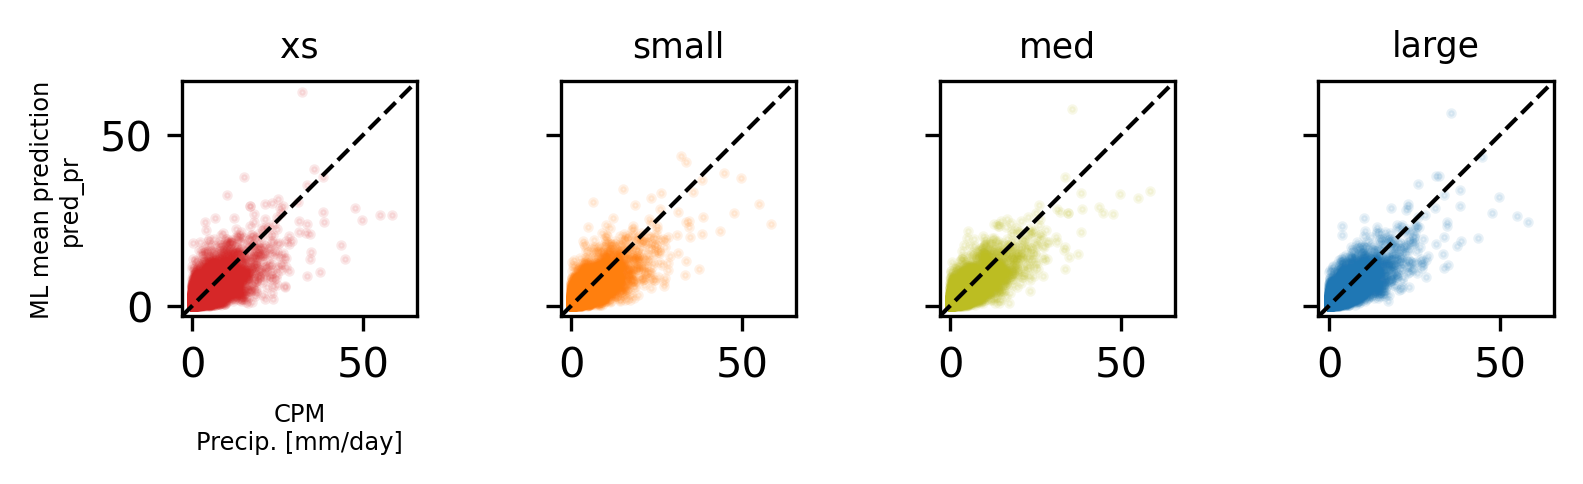

#### London JJA

,grid_latitude,grid_longitude,pr domain mean corr
model,,,
xs,-0.97,362,0.373
small,-0.97,362,0.44
med,-0.97,362,0.497
large,-0.97,362,0.486


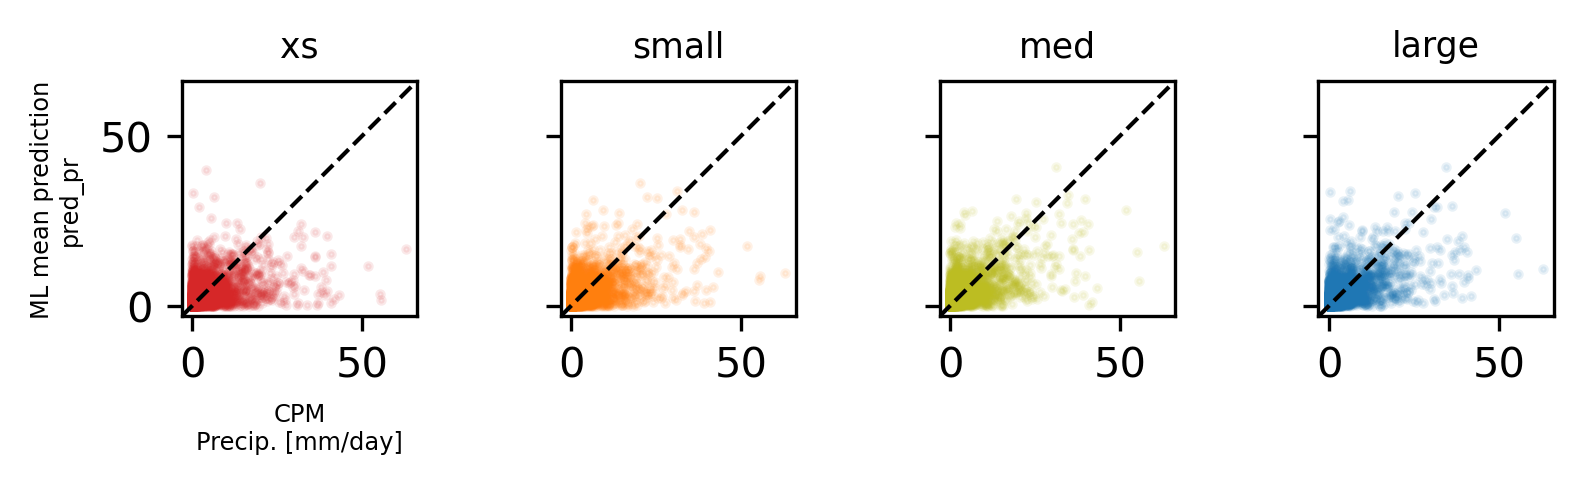

#### Lancaster DJF

,grid_latitude,grid_longitude,pr domain mean corr
model,,,
xs,1.51,360,0.634
small,1.51,360,0.702
med,1.51,360,0.74
large,1.51,360,0.734


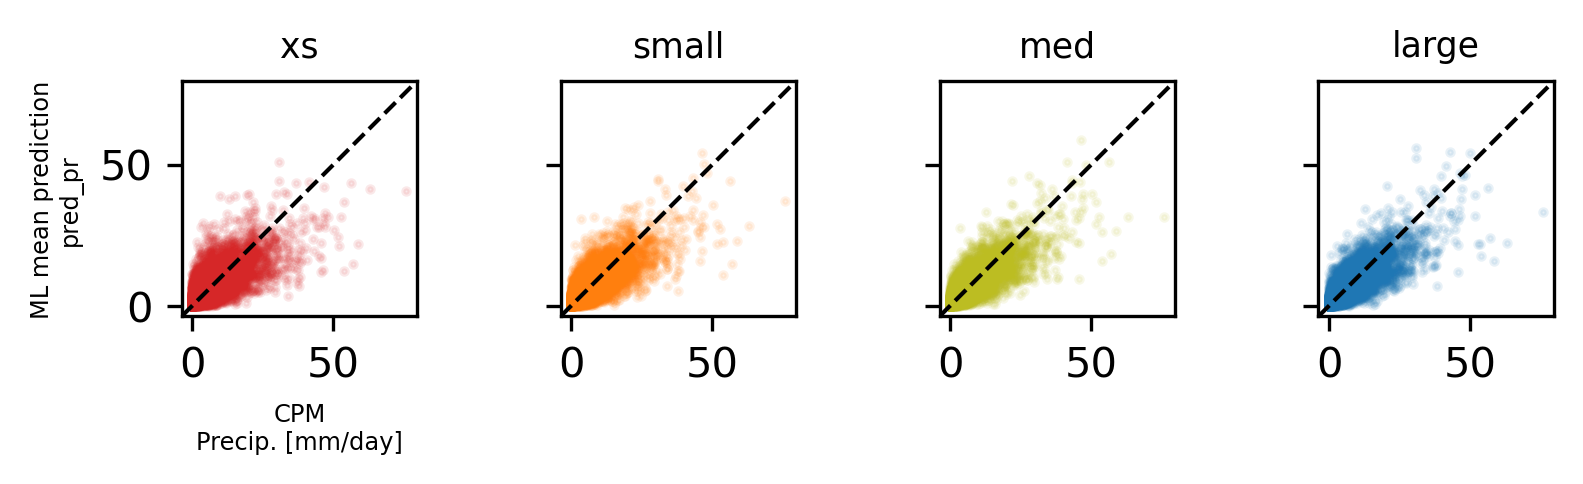

#### Lancaster JJA

,grid_latitude,grid_longitude,pr domain mean corr
model,,,
xs,1.51,360,0.486
small,1.51,360,0.52
med,1.51,360,0.567
large,1.51,360,0.569


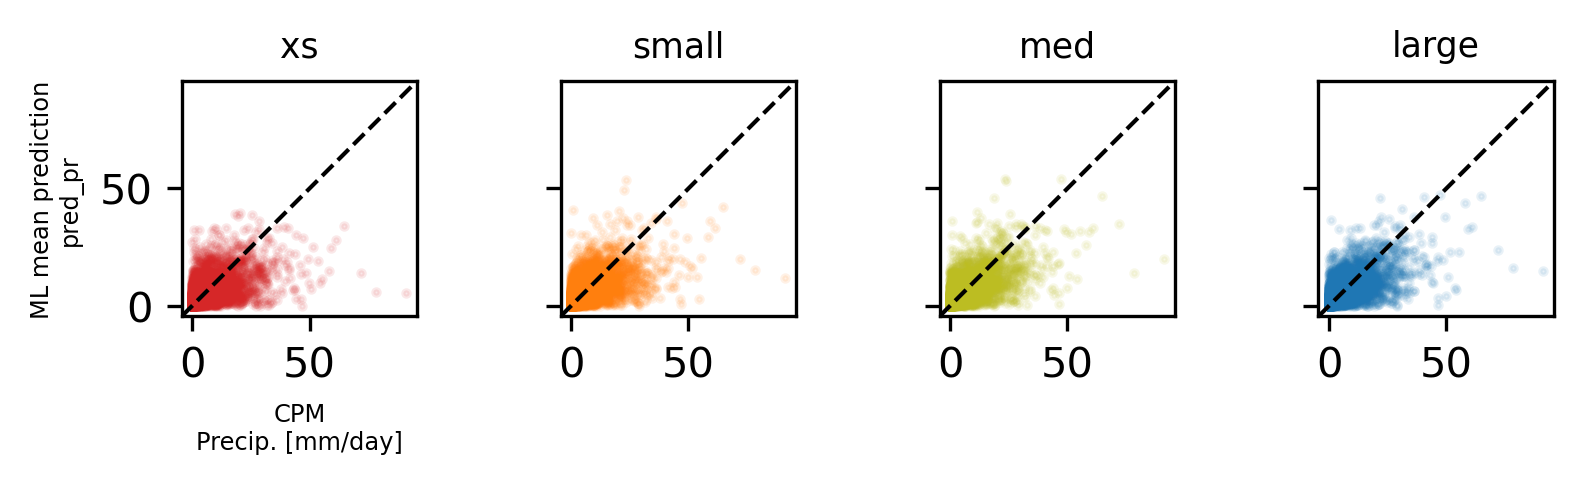

In [ ]:
for var in eval_vars:
    IPython.display.display_markdown(f"### {var}", raw=True)

    for label, q in BOX_LOCATIONS.items():
        ds = EVAL_DS["CPM"].cf.sel(**q, method="nearest")

        
        
        for season, season_ds in ds.groupby("time.season"):
            if season not in ["DJF", "JJA"]: continue

            IPython.display.display_markdown(f"#### {label} {season}", raw=True)
            fig = plt.figure(layout="constrained", figsize=(5.5, 1.5))
            axd = fig.subplot_mosaic(ds["model"].values.reshape(1,-1), sharey=True)
            
            pretty_table(
                xr.corr(season_ds[f"pred_{var}"], season_ds[f"target_{var}"], dim=["ensemble_member", "time", "sample_id"]).rename(f"{var} domain mean corr"),
                round=3,
            )
            
            for model, season_model_ds in season_ds.groupby("model"):
                pred_da = season_model_ds[f"pred_{var}"]
                cpm_da = season_model_ds[f"target_{var}"]
                if MODELLABEL2SPEC[model]["deterministic"]:
                    # don't let deterministic models appear brighter due to repeated predictions
                    pred_da = pred_da.isel(sample_id=[0])
                else:
                    # for generative models, consider the mean of the predictions
                    pred_da = pred_da.mean(dim="sample_id")
                
                ax = axd[model]
                ax.plot(
                    cpm_da.broadcast_like(pred_da).values.flat,
                    pred_da.values.flat,
                    alpha=0.1,
                    color=MODELLABEL2SPEC[model]["color"],
                    marker=".",
                    markersize=3,
                    linewidth=0,
                )
                ax.set_title(model, fontsize="small",)
                
                lims = [
                    np.min([ax.get_xlim(), ax.get_ylim()]),
                    np.max([ax.get_xlim(), ax.get_ylim()]),
                ]
                ax.set_aspect("equal")
                ax.set_xlim(lims)
                ax.set_ylim(lims)
                ax.plot(
                    [0, 1],
                    [0, 1],
                    transform=ax.transAxes,
                    linewidth=1,
                    color="black",
                    linestyle="--",
                    label="Ideal",
                )
    
            ax = list(axd.values())[0]
            ax.set_xlabel(
                f"CPM\n{xr.plot.utils.label_from_attrs(da=cpm_da)}",
                fontsize="xx-small",
            )
            ax.set_ylabel(
                f"ML mean prediction\n{xr.plot.utils.label_from_attrs(da=pred_da)}",
                fontsize="xx-small",
            )
            plt.show()

## Figure: Threshold exceedence

Threshold: 0.1mm/day 
 
 
   
   
 % Threshold exceeded 
 
 
 season 
 model 
   
 
 
 
 
 Annual 
 xs 
 53.2 
 
 
 small 
 53.0 
 
 
 med 
 52.9 
 
 
 large 
 52.6 
 
 
 CPM 
 53.0 
 
 
 DJF 
 xs 
 66.2 
 
 
 small 
 66.5 
 
 
 med 
 66.6 
 
 
 large 
 66.4 
 
 
 CPM 
 67.4 
 
 
 MAM 
 xs 
 57.8 
 
 
 small 
 57.3 
 
 
 med 
 56.7 
 
 
 large 
 56.2 
 
 
 CPM 
 55.7 
 
 
 JJA 
 xs 
 38.4 
 
 
 small 
 37.5 
 
 
 med 
 37.2 
 
 
 large 
 36.9 
 
 
 CPM 
 36.9 
 
 
 SON 
 xs 
 50.4 
 
 
 small 
 50.4 
 
 
 med 
 51.0 
 
 
 large 
 50.8 
 
 
 CPM 
 52.0

#### Threshold: 0.1mm/day

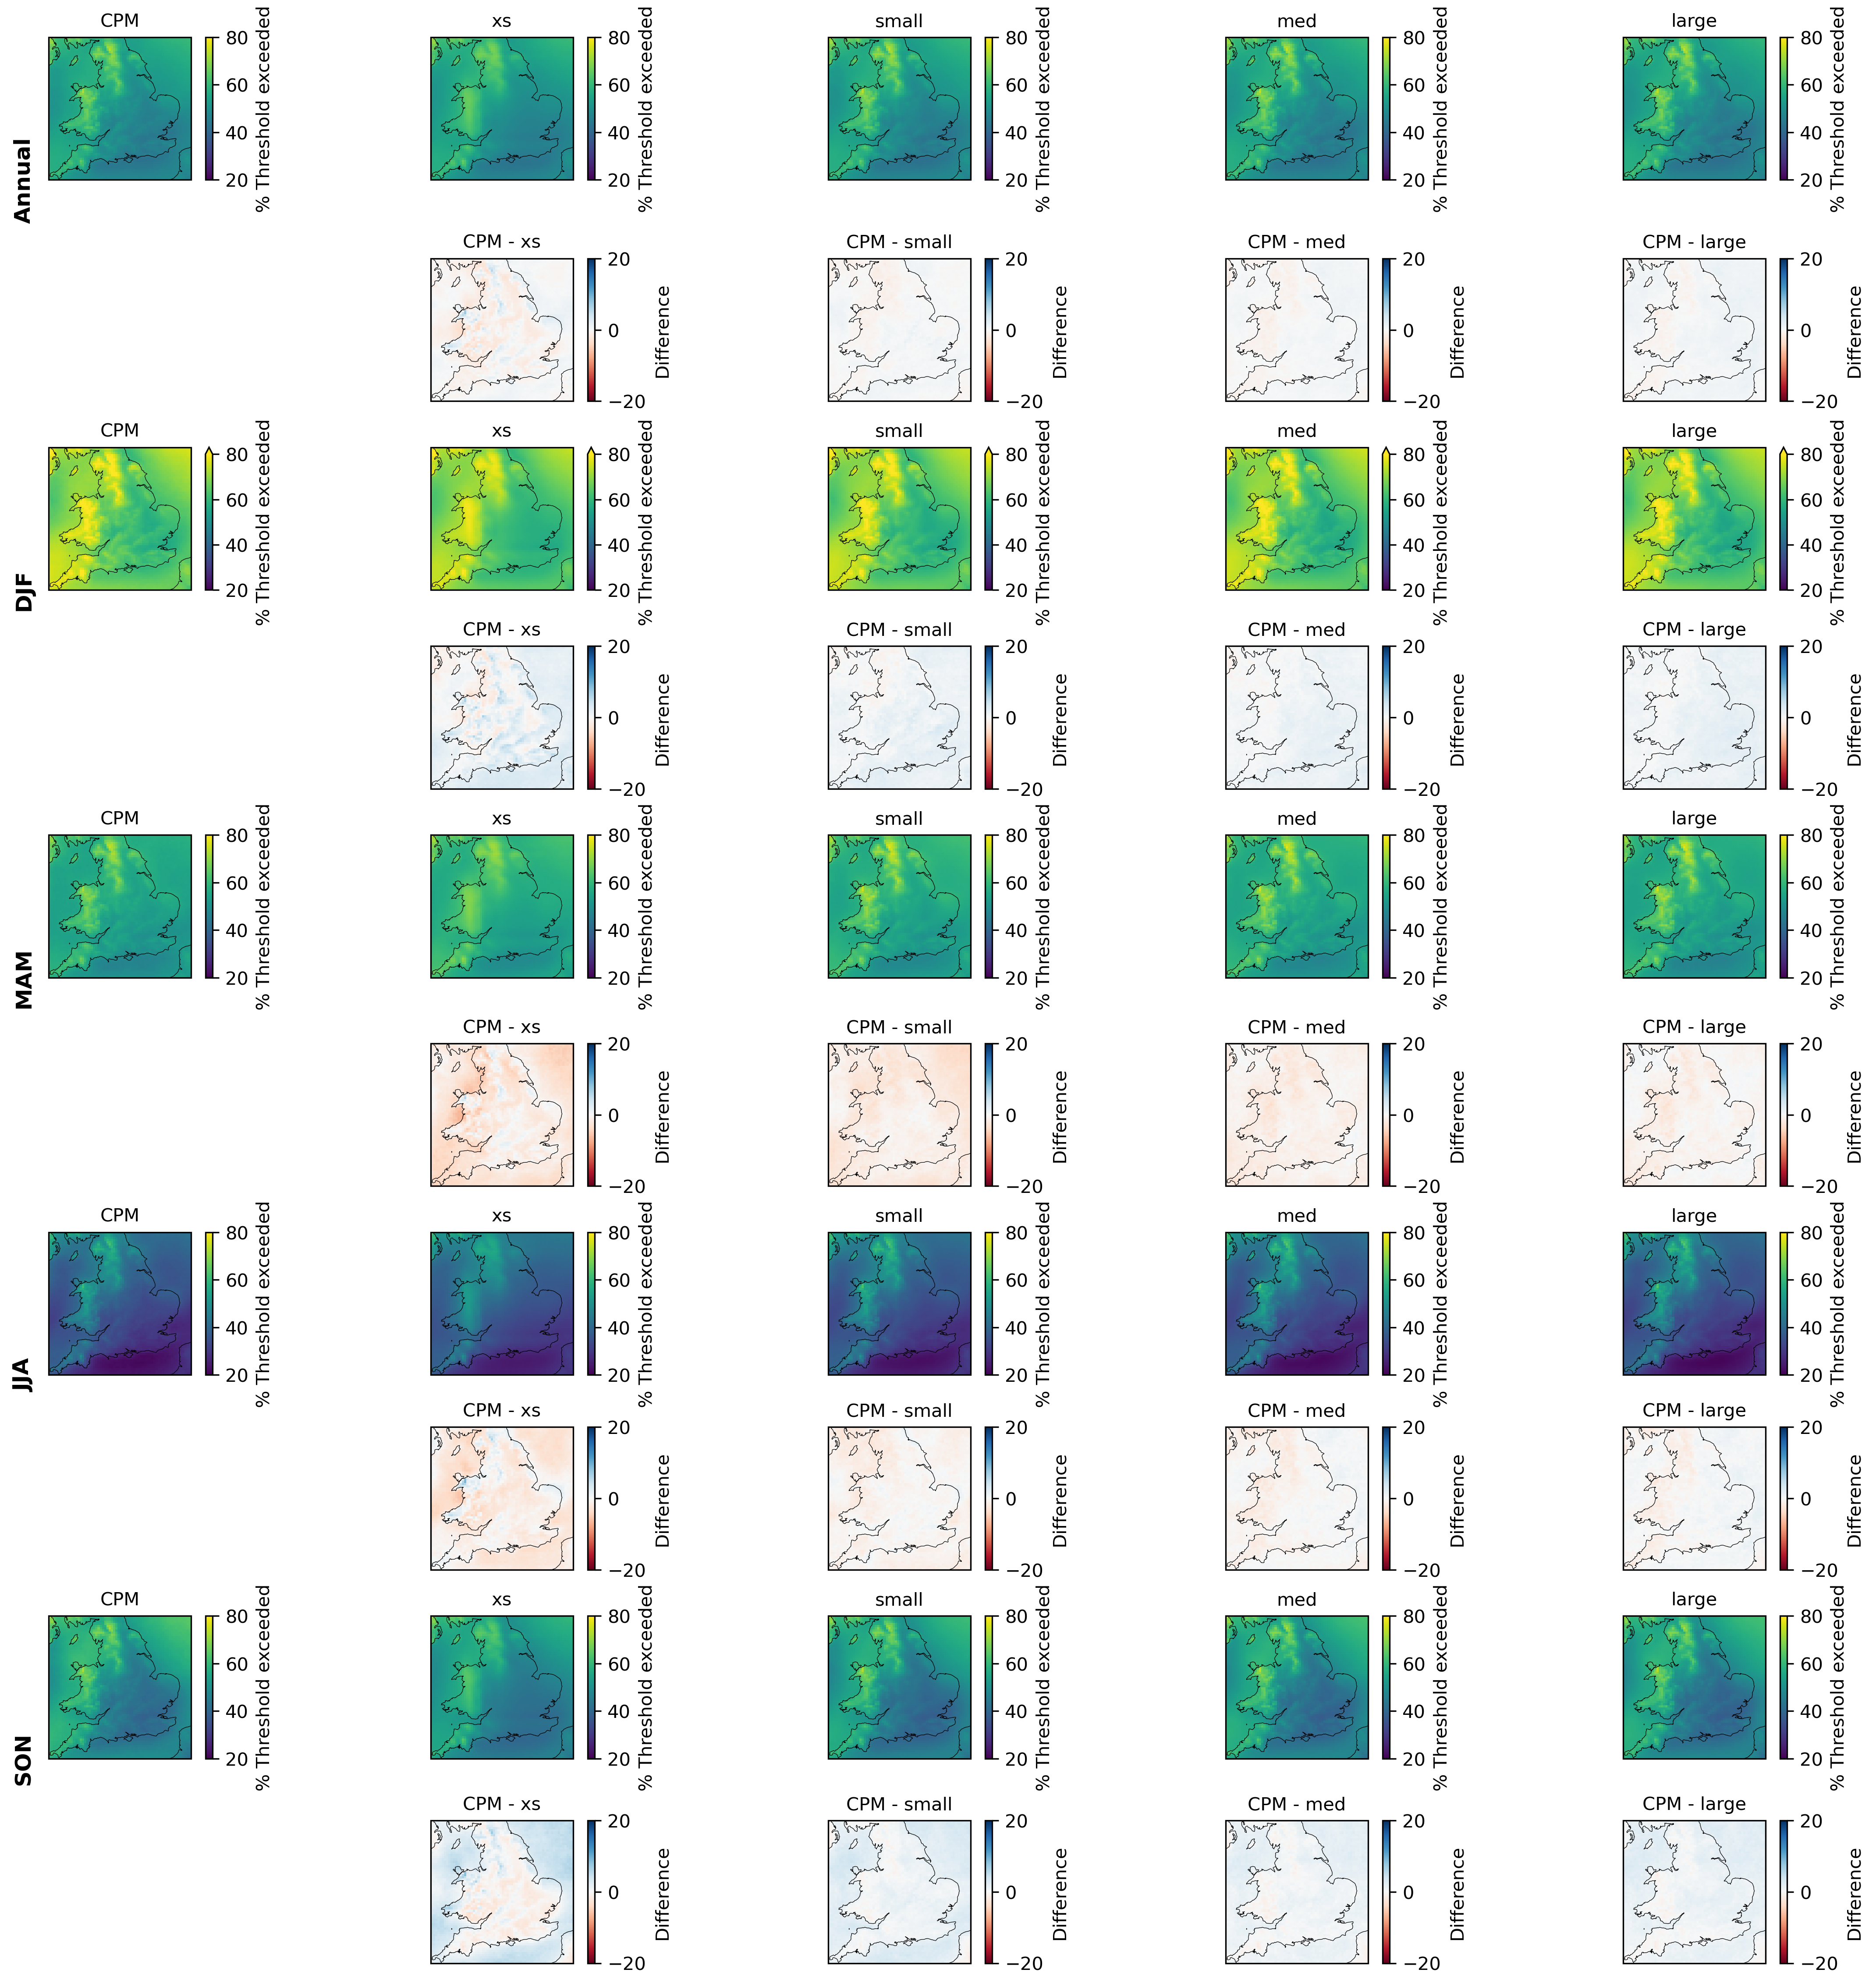

In [ ]:
for var, thresholds in THRESHOLDS.items():
    if var in eval_vars:
        model_das = [
            EVAL_DS[source][f"pred_{var}"].sel(model=model)
            for source, mconfigs in MODELS.items() for model, spec in mconfigs.items()
        ]

        threshold_exceeded_stats = { threshold: threshold_exceeded_prop_stats(VAR_DAS[var][f"pred_{var}"], CPM_DAS[var], threshold) for threshold in thresholds }

        dfs = [threshold_exceeded_stats[threshold].mean(dim=["grid_latitude", "grid_longitude"]).to_dataframe().style.set_table_attributes("style='display:inline'").set_caption(f"Threshold: {threshold}{CPM_DAS[var].attrs['units']}").format(precision=1).to_html() for threshold in thresholds]

        IPython.display.display_html(functools.reduce(lambda v, e: v+e, dfs), raw=True)

        for threshold in thresholds:
            IPython.display.display_markdown(f"#### Threshold: {threshold}{CPM_DAS[var].attrs['units']}", raw=True)

            plot_threshold_exceedence_errors(threshold_exceeded_stats[threshold])

            plt.show()

## Rough: wet-day mean

#### Threshold: 0.1mm/day

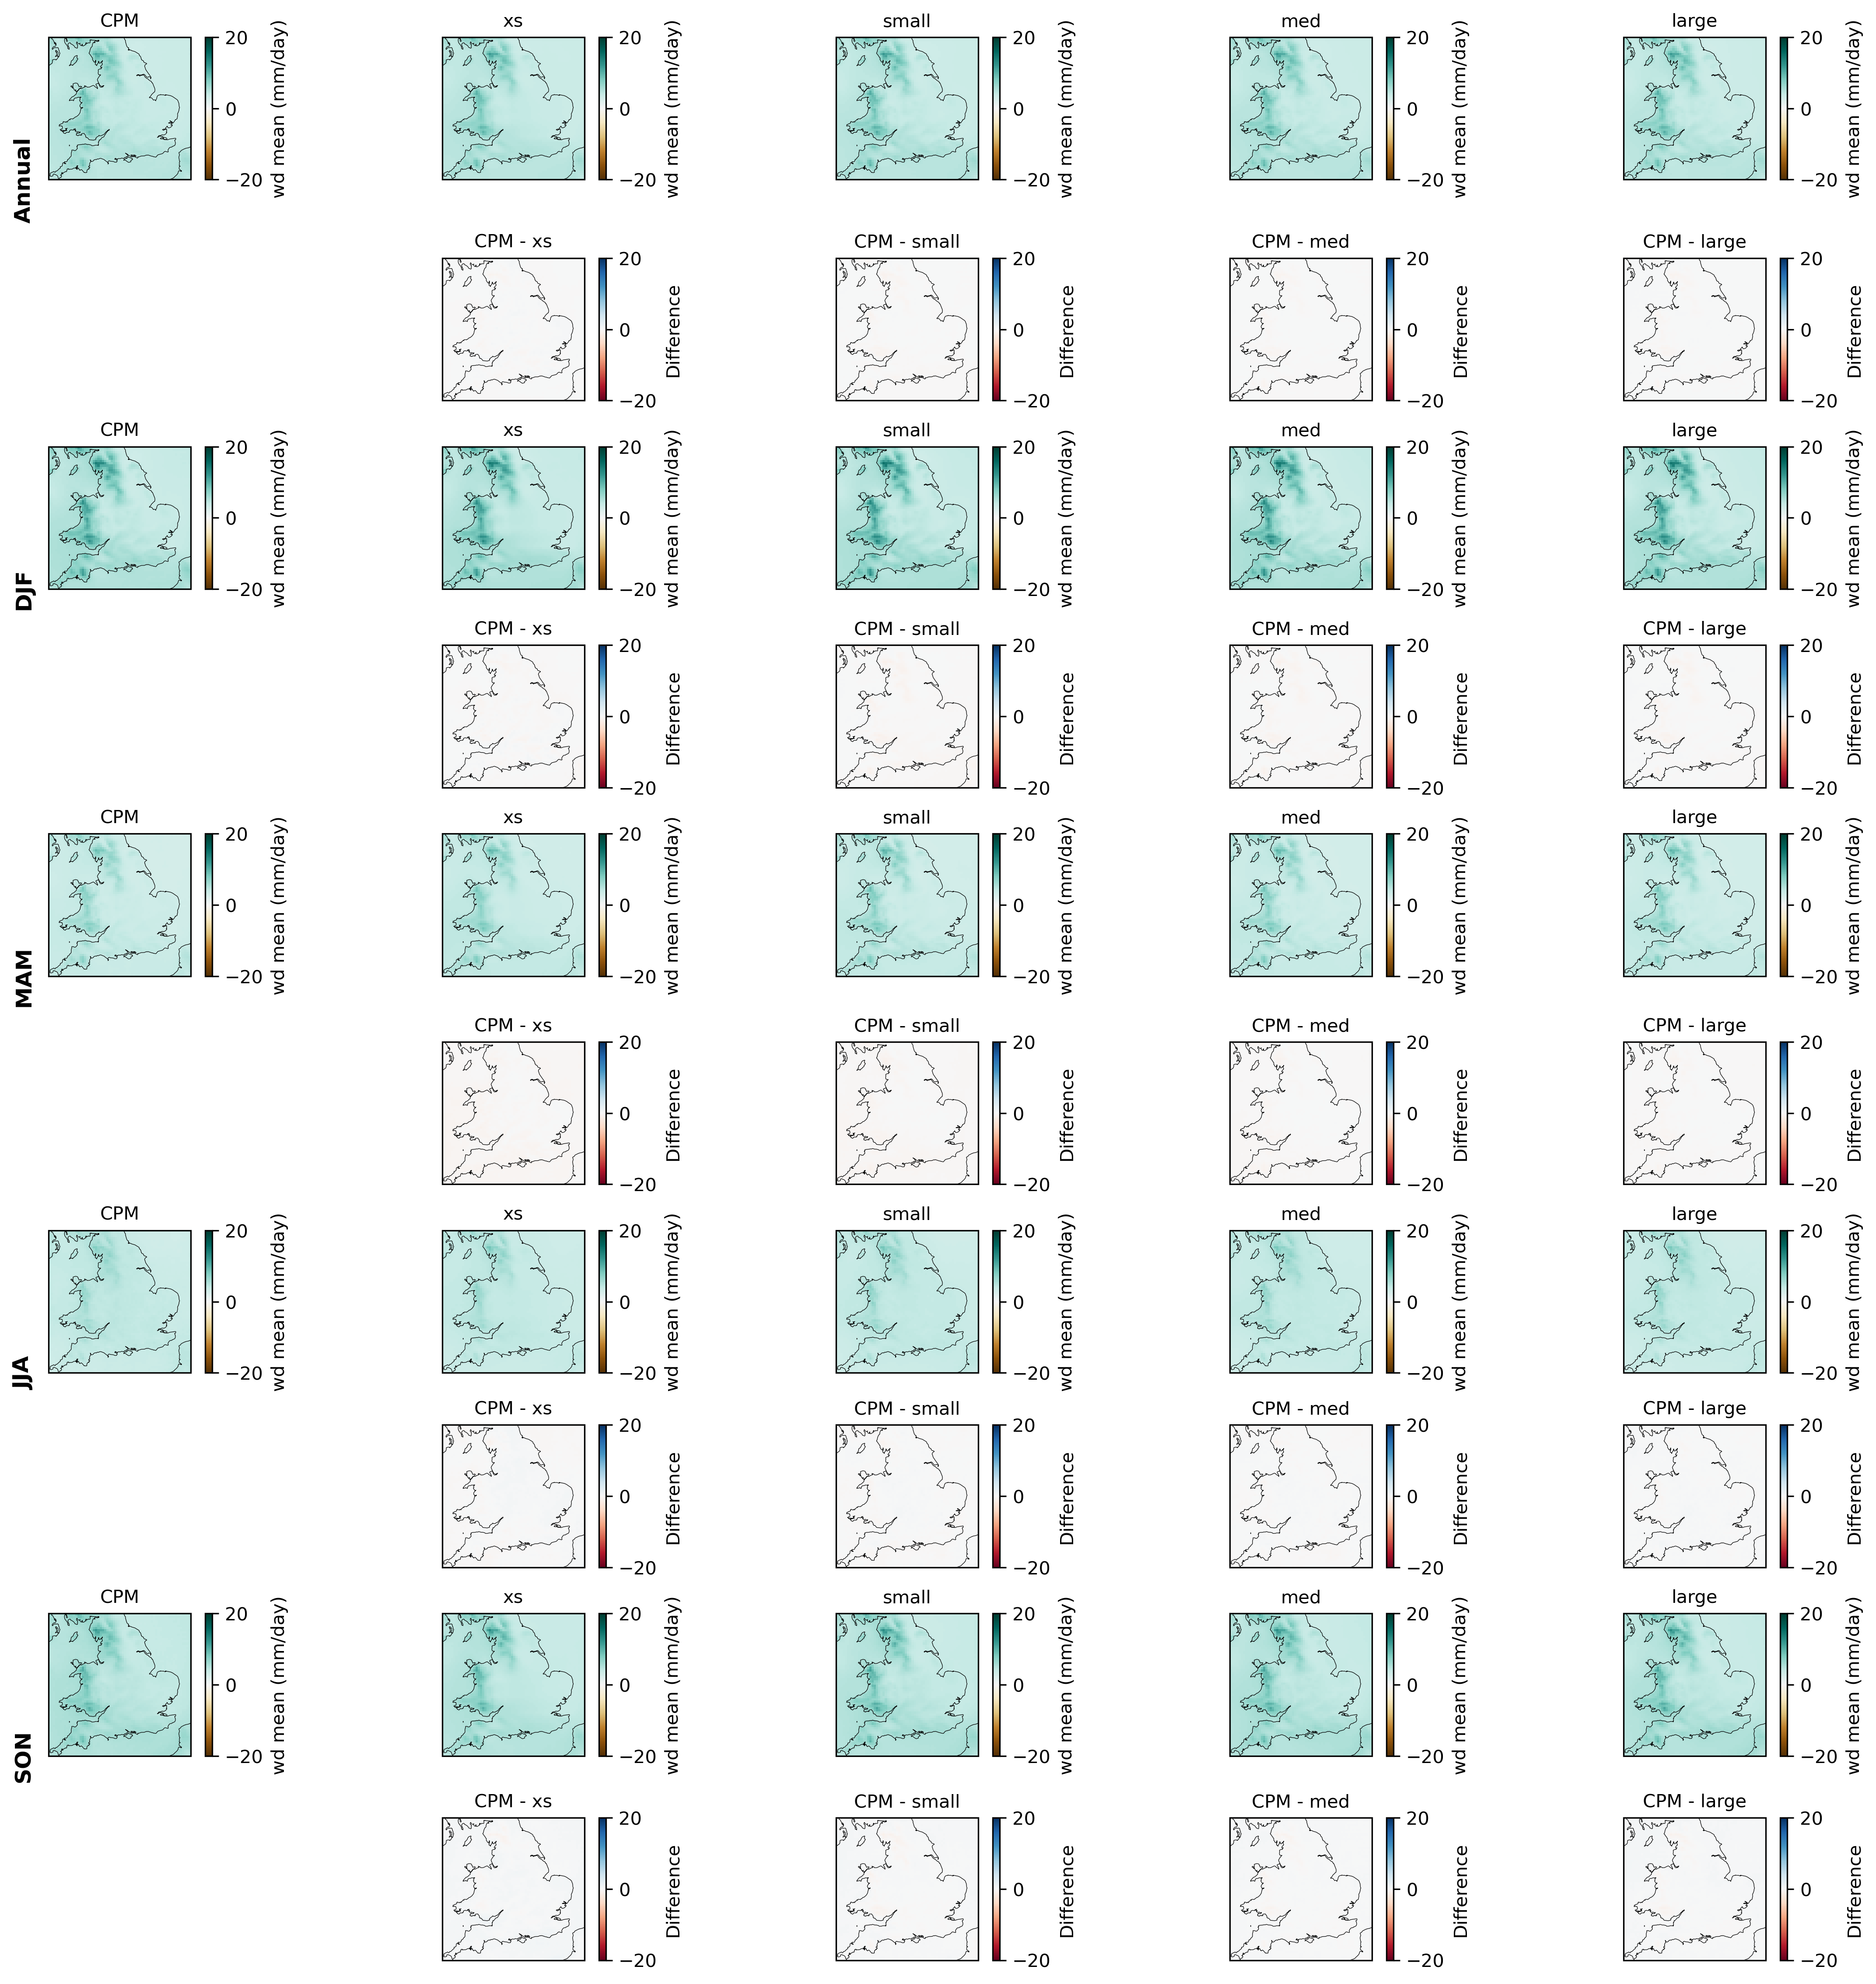

In [ ]:
model_das = [
    EVAL_DS[source]["pred_pr"].sel(model=model)
    for source, mconfigs in MODELS.items() for model, spec in mconfigs.items()
]

change_stats = { var: { threshold: threshold_exceeded_prop_stats(VAR_DAS[var][f"pred_{var}"], CPM_DAS[var], threshold=threshold, threshold_exceeded_prop_statistic=wd_mean) for threshold in thresholds } for var, thresholds in THRESHOLDS.items() if var in eval_vars }

for var, thresholds in THRESHOLDS.items():
    if var in eval_vars:
        for threshold in thresholds:
            IPython.display.display_markdown(f"#### Threshold: {threshold}mm/day", raw=True)
            
            plot_threshold_exceedence_errors(change_stats[var][threshold], style="change")
        
            plt.show()